# **Final Capstone Project**

# **Libraries Importing**

In [2]:
# Import the required libraries
import numpy as np
import requests
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf
import folium
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
# Fetch data from SpaceX REST API
spacex_url="https://api.spacexdata.com/v4/launches"
response = requests.get(spacex_url)
spacex_launches = response.json()

spacex_df = pd.DataFrame(spacex_launches)

In [4]:
# Extract data from Wikipedia pages
def get_wikipedia_data(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')

    data = {}
    # Example: Extracting title as a placeholder
    title = soup.find('h1')
    if title:
        data['title'] = title.text
    # More extraction logic would be needed based on specific Wikipedia page structure

    return data

In [8]:
# Placeholder list for Wikipedia URLs
wikipedia_urls = [
    "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches_(2010%E2%80%932019)",
    "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches_(2020%E2%80%932022)"
]

wikipedia_data = []
for url in wikipedia_urls:
    data = get_wikipedia_data(url)
    if data:
        wikipedia_data.append(data)

wikipedia_df = pd.DataFrame(wikipedia_data)

In [11]:
print("SpaceX DataFrame Head:")
display(spacex_df.head())
print("\nWikipedia DataFrame Head:")
display(wikipedia_df.head())

SpaceX DataFrame Head:


,fairings,links,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,...,date_utc,date_unix,date_local,date_precision,upcoming,cores,auto_update,tbd,launch_library_id,id
0,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,...,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight'...",True,False,None,5eb87cd9ffd86e000604b32a
1,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,...,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight'...",True,False,None,5eb87cdaffd86e000604b32b
2,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,...,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight'...",True,False,None,5eb87cdbffd86e000604b32c
3,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],Ratsat was carried to orbit on the first succe...,...,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight'...",True,False,None,5eb87cdbffd86e000604b32d
4,"{'reused': False, 'recovery_attempt': False, '...",{'patch': {'small': 'https://images2.imgbox.co...,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,True,[],None,...,2009-07-13T03:35:00.000Z,1247456100,2009-07-13T15:35:00+12:00,hour,False,"[{'core': '5e9e289ef359184f103b2627', 'flight'...",True,False,None,5eb87cdcffd86e000604b32e



Wikipedia DataFrame Head:


""


# **Data Wrangling**

In [12]:
# Select relevant columns
selected_columns = ['fairings', 'links', 'net', 'date_utc', 'success', 'cores', 'capsules', 'payloads', 'launchpad', 'flight_number', 'name']
df = spacex_df[selected_columns].copy()

# Extract landing outcome from 'cores' and 'fairings'
def get_landing_outcome(row):
    if row['cores']:
        # Assuming the first core is the primary one for landing attempt
        core = row['cores'][0]
        if core and 'landing_success' in core and core['landing_success'] is not None:
            return core['landing_success']
    if row['fairings'] and 'recovery_attempt' in row['fairings'] and row['fairings']['recovery_attempt']:
         # If fairings recovery was attempted, assume landing success if the overall mission was a success
         # This is a simplification, a more detailed approach might be needed with more data
         return row['success']
    return None

df['landing_success'] = df.apply(get_landing_outcome, axis=1)

# Handle missing values in selected columns
# For 'landing_success', fill None with False (assuming no landing attempt means no success)
df['landing_success'] = df['landing_success'].fillna(False)

# For other columns, drop rows where essential information is missing (e.g., launch success)
df.dropna(subset=['success', 'date_utc', 'launchpad', 'landing_success'], inplace=True)

# Handle missing values in 'net' by filling with False (assuming not net means not net)
df['net'] = df['net'].fillna(False)

# Convert 'date_utc' to datetime and extract year
df['date_utc'] = pd.to_datetime(df['date_utc'])
df['year'] = df['date_utc'].dt.year

# Extract launchpad ID
df['launchpad_id'] = df['launchpad']

# Drop original nested columns and date_utc, launchpad
df.drop(columns=['fairings', 'links', 'cores', 'capsules', 'payloads', 'date_utc', 'launchpad'], inplace=True)

# Ensure target variable is boolean or integer (0/1)
df['landing_success'] = df['landing_success'].astype(int)

display(df.head())

/tmp/ipython-input-2032034239.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['landing_success'] = df['landing_success'].fillna(False)


,net,success,flight_number,name,landing_success,year,launchpad_id
0,False,False,1,FalconSat,0,2006,5e9e4502f5090995de566f86
1,False,False,2,DemoSat,0,2007,5e9e4502f5090995de566f86
2,False,False,3,Trailblazer,0,2008,5e9e4502f5090995de566f86
3,False,True,4,RatSat,0,2008,5e9e4502f5090995de566f86
4,False,True,5,RazakSat,0,2009,5e9e4502f5090995de566f86


In [13]:
# Apply one-hot encoding to categorical features
categorical_columns = ['launchpad_id']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

display(df.head())

,net,success,flight_number,name,landing_success,year,launchpad_id_5e9e4502f509092b78566f87,launchpad_id_5e9e4502f509094188566f88,launchpad_id_5e9e4502f5090995de566f86
0,False,False,1,FalconSat,0,2006,False,False,True
1,False,False,2,DemoSat,0,2007,False,False,True
2,False,False,3,Trailblazer,0,2008,False,False,True
3,False,True,4,RatSat,0,2008,False,False,True
4,False,True,5,RazakSat,0,2009,False,False,True


# **Exploratory Data Analysis (EDA)**

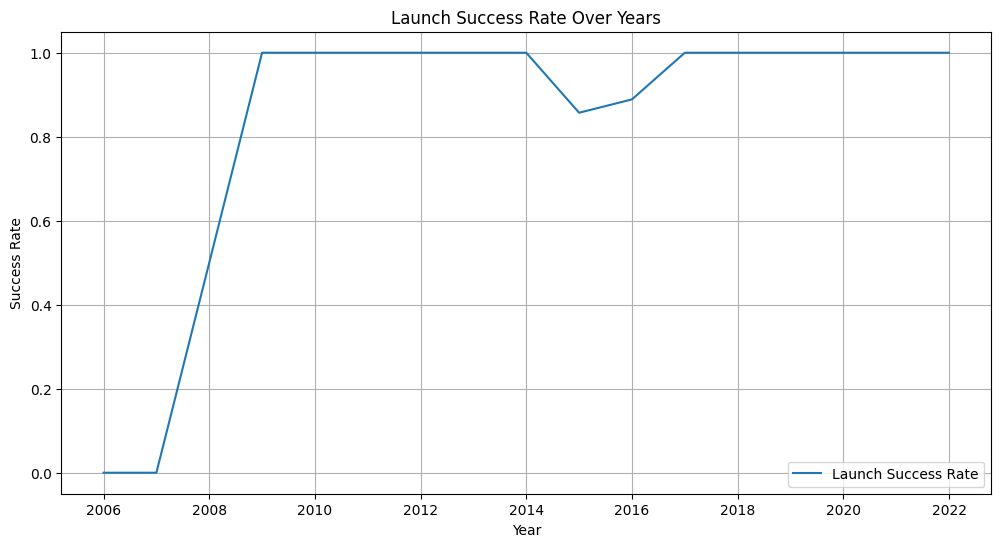

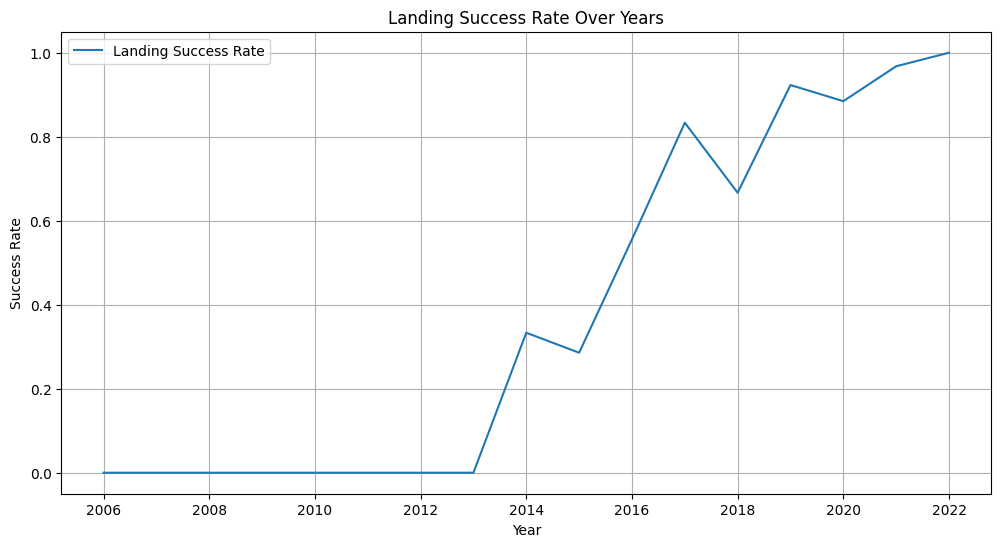

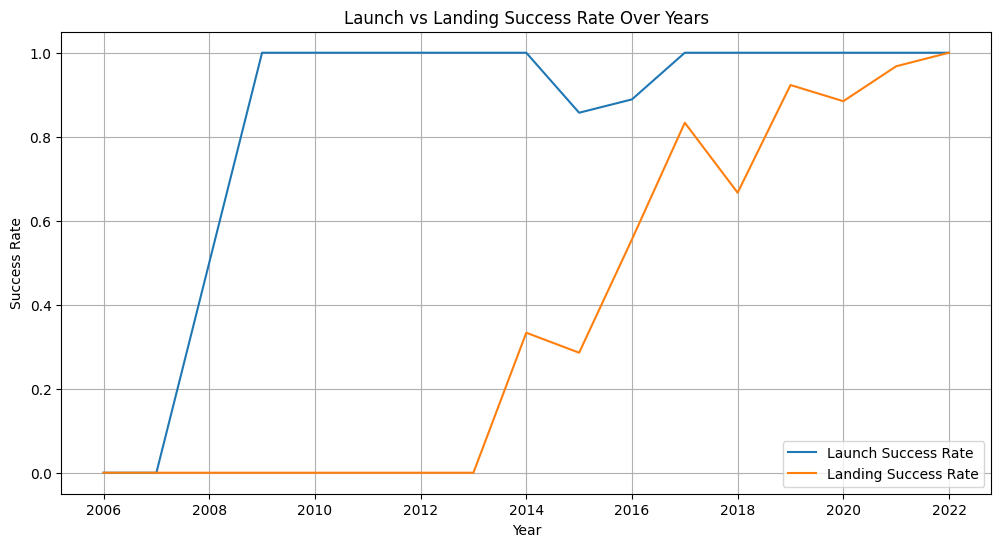

In [14]:
# Calculate launch success rate by year
launch_success_rate_by_year = df.groupby('year')['success'].mean()

# Calculate landing success rate by year
landing_success_rate_by_year = df.groupby('year')['landing_success'].mean()

# Plot launch success rate by year
plt.figure(figsize=(12, 6))
sns.lineplot(x=launch_success_rate_by_year.index, y=launch_success_rate_by_year.values, label='Launch Success Rate')
plt.title('Launch Success Rate Over Years')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.grid(True)
plt.show()

# Plot landing success rate by year
plt.figure(figsize=(12, 6))
sns.lineplot(x=landing_success_rate_by_year.index, y=landing_success_rate_by_year.values, label='Landing Success Rate')
plt.title('Landing Success Rate Over Years')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.grid(True)
plt.show()

# Compare launch and landing success rates over years
plt.figure(figsize=(12, 6))
sns.lineplot(x=launch_success_rate_by_year.index, y=launch_success_rate_by_year.values, label='Launch Success Rate')
sns.lineplot(x=landing_success_rate_by_year.index, y=landing_success_rate_by_year.values, label='Landing Success Rate')
plt.title('Launch vs Landing Success Rate Over Years')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.legend()
plt.grid(True)
plt.show()

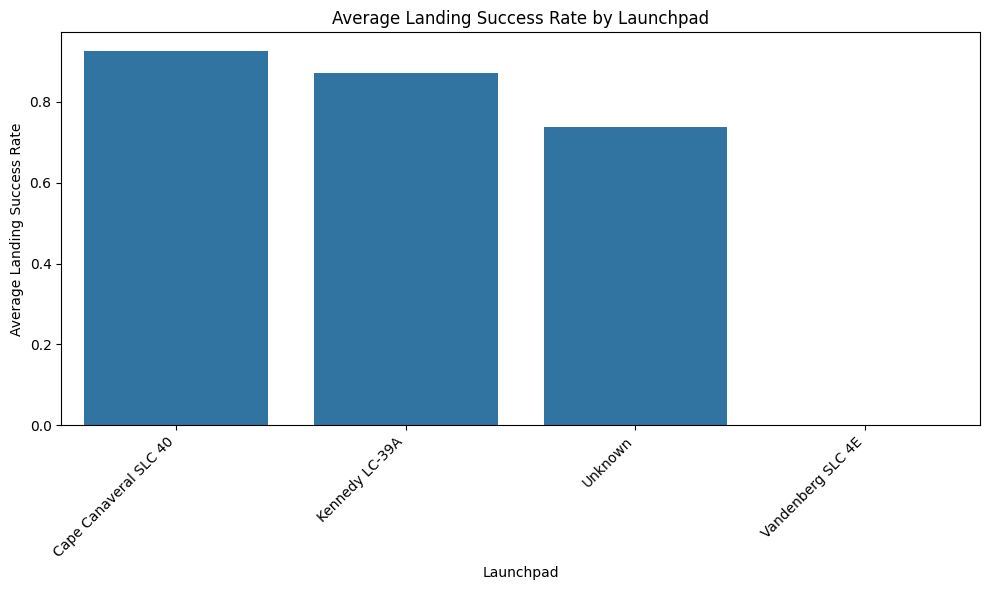

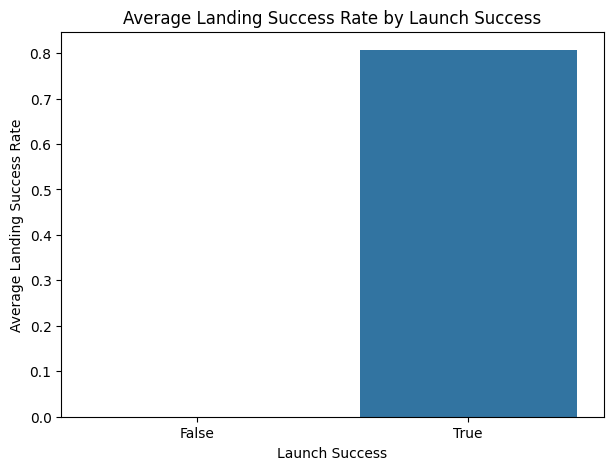

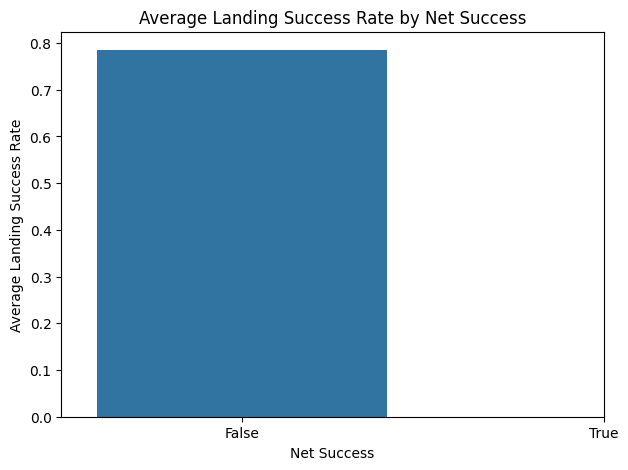

In [15]:
# Calculate average landing success rate by launchpad
landing_success_rate_by_launchpad_5e9e4502f509092b78566f87 = df.groupby('launchpad_id_5e9e4502f509092b78566f87')['landing_success'].mean().loc[True]
landing_success_rate_by_launchpad_5e9e4502f509094188566f88 = df.groupby('launchpad_id_5e9e4502f509094188566f88')['landing_success'].mean().loc[True]
landing_success_rate_by_launchpad_5e9e4502f5090995de566f86 = df.groupby('launchpad_id_5e9e4502f5090995de566f86')['landing_success'].mean().loc[True]

# Need to get the average landing success rate for 'Unknown' launchpads as well
# This can be done by filtering the original df where none of the launchpad_id columns are True
unknown_launchpad_success_rate = df[(df['launchpad_id_5e9e4502f509092b78566f87'] == False) &
                                     (df['launchpad_id_5e9e4502f509094188566f88'] == False) &
                                     (df['launchpad_id_5e9e4502f5090995de566f86'] == False)]['landing_success'].mean()


# Combine the series using concat - including the unknown launchpad rate
landing_success_rate_by_launchpad = pd.Series([
    landing_success_rate_by_launchpad_5e9e4502f509092b78566f87,
    landing_success_rate_by_launchpad_5e9e4502f509094188566f88,
    unknown_launchpad_success_rate, # Use the unknown launchpad rate here
    landing_success_rate_by_launchpad_5e9e4502f5090995de566f86 # Keep Vandenberg's rate as it was part of the original one-hot encoding
])


# Add launchpad names for clarity
launchpad_names = ['Cape Canaveral SLC 40', 'Kennedy LC-39A', 'Unknown', 'Vandenberg SLC 4E'] # Added Unknown and kept Vandenberg
landing_success_rate_by_launchpad.index = launchpad_names


# Plot average landing success rate by launchpad
plt.figure(figsize=(10, 6))
sns.barplot(x=landing_success_rate_by_launchpad.index, y=landing_success_rate_by_launchpad.values)
plt.title('Average Landing Success Rate by Launchpad')
plt.xlabel('Launchpad')
plt.ylabel('Average Landing Success Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate average landing success rate by launch success
landing_success_rate_by_launch_success = df.groupby('success')['landing_success'].mean()

# Plot average landing success rate by launch success
plt.figure(figsize=(7, 5))
sns.barplot(x=landing_success_rate_by_launch_success.index, y=landing_success_rate_by_launch_success.values)
plt.title('Average Landing Success Rate by Launch Success')
plt.xlabel('Launch Success')
plt.ylabel('Average Landing Success Rate')
plt.xticks([0, 1], ['False', 'True'])
plt.show()

# Calculate average landing success rate by net success
landing_success_rate_by_net_success = df.groupby('net')['landing_success'].mean()

# Plot average landing success rate by net success
plt.figure(figsize=(7, 5))
sns.barplot(x=landing_success_rate_by_net_success.index, y=landing_success_rate_by_net_success.values)
plt.title('Average Landing Success Rate by Net Success')
plt.xlabel('Net Success')
plt.ylabel('Average Landing Success Rate')
plt.xticks([0, 1], ['False', 'True'])
plt.show()

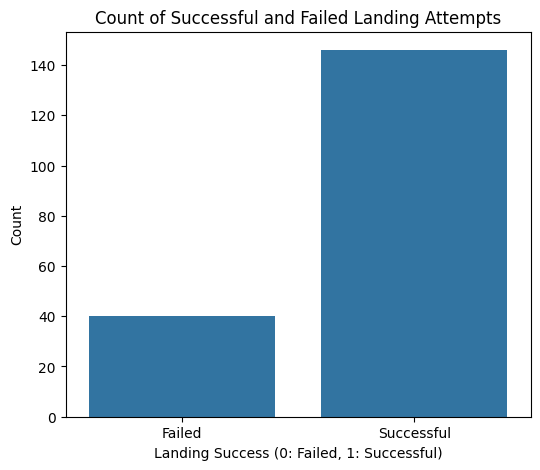

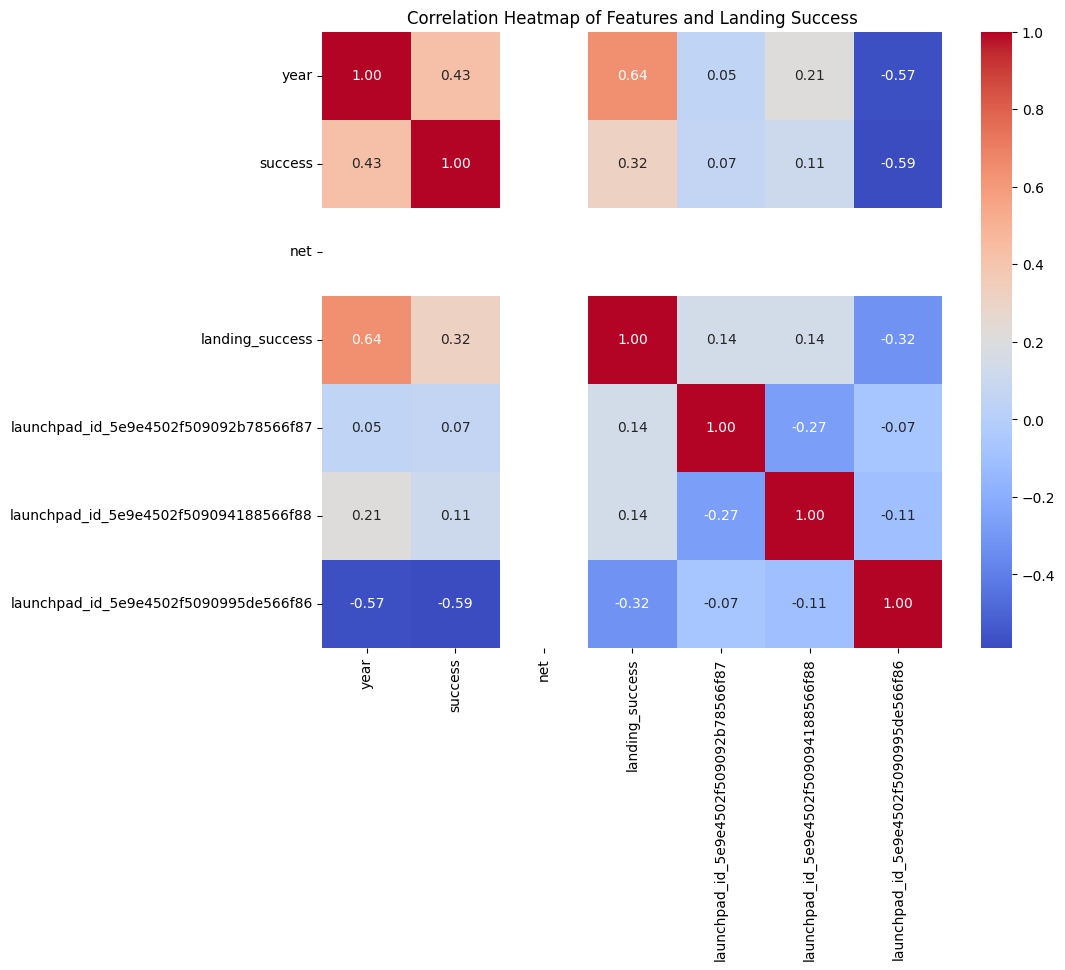

In [16]:
# Count of Landing Outcomes
plt.figure(figsize=(6, 5))
sns.countplot(x='landing_success', data=df)
plt.title('Count of Successful and Failed Landing Attempts')
plt.xlabel('Landing Success (0: Failed, 1: Successful)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Failed', 'Successful'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[['year', 'success', 'net', 'landing_success',
                         'launchpad_id_5e9e4502f509092b78566f87',
                         'launchpad_id_5e9e4502f509094188566f88',
                         'launchpad_id_5e9e4502f5090995de566f86']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features and Landing Success')
plt.show()


In [17]:
from pandasql import sqldf

# Register the dataframe with pandasql
pysqldf = lambda q: sqldf(q, globals())

# Find the number of launches per launchpad
q1 = """
SELECT
    CASE
        WHEN launchpad_id_5e9e4502f509092b78566f87 = 1 THEN 'Cape Canaveral SLC 40'
        WHEN launchpad_id_5e9e4502f509094188566f88 = 1 THEN 'Kennedy LC-39A'
        WHEN launchpad_id_5e9e4502f5090995de566f86 = 1 THEN 'Vandenberg SLC 4E'
        ELSE 'Unknown'
    END AS launchpad,
    COUNT(*) AS number_of_launches
FROM df
GROUP BY launchpad;
"""
launches_per_launchpad = pysqldf(q1)
print("Number of launches per launchpad:")
display(launches_per_launchpad)

# Find the average landing success rate per launchpad
q2 = """
SELECT
    CASE
        WHEN launchpad_id_5e9e4502f509092b78566f87 = 1 THEN 'Cape Canaveral SLC 40'
        WHEN launchpad_id_5e9e4502f509094188566f88 = 1 THEN 'Kennedy LC-39A'
        WHEN launchpad_id_5e9e4502f5090995de566f86 = 1 THEN 'Vandenberg SLC 4E'
        ELSE 'Unknown'
    END AS launchpad,
    AVG(landing_success) AS average_landing_success_rate
FROM df
GROUP BY launchpad;
"""
avg_landing_success_by_launchpad_sql = pysqldf(q2)
print("\nAverage landing success rate per launchpad:")
display(avg_landing_success_by_launchpad_sql)

# Find the total number of successful landing attempts and the total number of failed landing attempts
q3 = """
SELECT
    SUM(landing_success) AS successful_landings,
    COUNT(*) - SUM(landing_success) AS failed_landings
FROM df;
"""
landing_attempts_summary = pysqldf(q3)
print("\nTotal number of successful and failed landing attempts:")
display(landing_attempts_summary)

# Find the year with the highest landing success rate
q4 = """
SELECT
    year,
    AVG(landing_success) AS average_landing_success_rate
FROM df
GROUP BY year
ORDER BY average_landing_success_rate DESC
LIMIT 1;
"""
year_highest_landing_success = pysqldf(q4)
print("\nYear with the highest landing success rate:")
display(year_highest_landing_success)

Number of launches per launchpad:


,launchpad,number_of_launches
0,Cape Canaveral SLC 40,27
1,Kennedy LC-39A,55
2,Unknown,99
3,Vandenberg SLC 4E,5



Average landing success rate per launchpad:


,launchpad,average_landing_success_rate
0,Cape Canaveral SLC 40,0.925926
1,Kennedy LC-39A,0.872727
2,Unknown,0.737374
3,Vandenberg SLC 4E,0.000000



Total number of successful and failed landing attempts:


,successful_landings,failed_landings
0,146,40



Year with the highest landing success rate:


,year,average_landing_success_rate
0,2022,1.0


# **Interactive Visual Analytics**

In [18]:
launchpad_coords = {
    'Cape Canaveral SLC 40': (28.5623, -80.5774),
    'Kennedy LC-39A': (28.608058, -80.603956),
    'Vandenberg SLC 4E': (34.632093, -120.610703),
    'Unknown': (0, 0) # Using (0,0) for unknown, will not plot accurately
}

launchpad_map_data = avg_landing_success_by_launchpad_sql.copy()
launchpad_map_data['lat'] = launchpad_map_data['launchpad'].apply(lambda x: launchpad_coords.get(x, (0,0))[0])
launchpad_map_data['lon'] = launchpad_map_data['launchpad'].apply(lambda x: launchpad_coords.get(x, (0,0))[1])

display(launchpad_map_data)

,launchpad,average_landing_success_rate,lat,lon
0,Cape Canaveral SLC 40,0.925926,28.562300,-80.577400
1,Kennedy LC-39A,0.872727,28.608058,-80.603956
2,Unknown,0.737374,0.000000,0.000000
3,Vandenberg SLC 4E,0.000000,34.632093,-120.610703


In [19]:
# Calculate the average coordinates of the known launchpads for centering the map
known_launchpads = launchpad_map_data[launchpad_map_data['launchpad'] != 'Unknown']
avg_lat = known_launchpads['lat'].mean()
avg_lon = known_launchpads['lon'].mean()

# Create a map centered around the average coordinates
m = folium.Map(location=[avg_lat, avg_lon], zoom_start=4)

# Add markers for each launchpad
for index, row in launchpad_map_data.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Launchpad: {row['launchpad']}<br>Average Landing Success Rate: {row['average_landing_success_rate']:.2f}",
        tooltip=row['launchpad']
    ).add_to(m)

# Display the map
display(m)

In [20]:
# Create an interactive bar chart showing the average landing success rate by launchpad
fig1 = px.bar(avg_landing_success_by_launchpad_sql,
             x='launchpad',
             y='average_landing_success_rate',
             title='Average Landing Success Rate by Launchpad')
fig1.show()

# Create an interactive line chart showing the landing success rate over the years
fig2 = px.line(landing_success_rate_by_year,
              x=landing_success_rate_by_year.index,
              y=landing_success_rate_by_year.values,
              labels={'x': 'Year', 'y': 'Average Landing Success Rate'},
              title='Landing Success Rate Over Years')
fig2.show()

# Convert the series to a DataFrame for Plotly Express
landing_success_rate_by_launch_success_df = landing_success_rate_by_launch_success.reset_index()
landing_success_rate_by_launch_success_df.columns = ['launch_success', 'average_landing_success_rate']

# Create an interactive bar chart showing the average landing success rate by launch success
fig3 = px.bar(landing_success_rate_by_launch_success_df,
             x='launch_success',
             y='average_landing_success_rate',
             title='Average Landing Success Rate by Launch Success')
fig3.show()

# Convert the series to a DataFrame for Plotly Express
landing_success_rate_by_net_success_df = landing_success_rate_by_net_success.reset_index()
landing_success_rate_by_net_success_df.columns = ['net_success', 'average_landing_success_rate']

# Create an interactive bar chart showing the average landing success rate by net success
fig4 = px.bar(landing_success_rate_by_net_success_df,
             x='net_success',
             y='average_landing_success_rate',
             title='Average Landing Success Rate by Net Success')
fig4.show()

In [21]:
# Landing Success Rate by Flight Number (using Plotly for interactivity)
fig5 = px.scatter(df,
                  x='flight_number',
                  y='landing_success',
                  title='Landing Success by Flight Number')
fig5.update_layout(yaxis_title='Landing Success (0: Failed, 1: Successful)')
fig5.show()


# Box Plot of Landing Success by Year (using Plotly for interactivity)
fig6 = px.box(df,
              x='year',
              y='landing_success',
              title='Landing Success Distribution by Year')
fig6.update_layout(yaxis_title='Landing Success (0: Failed, 1: Successful)')
fig6.show()

# **Predictive Analysis**

In [22]:
# Select features (X) and target (y)
features = ['year', 'success', 'net', 'launchpad_id_5e9e4502f509092b78566f87',
            'launchpad_id_5e9e4502f509094188566f88', 'launchpad_id_5e9e4502f5090995de566f86']
X = df[features]
y = df['landing_success']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear'),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}
tuned_models = {}

In [26]:
# Train, tune, and evaluate each model
for name, model in models.items():
    print(f"Training and evaluating {name}...")

    # Basic Hyperparameter Tuning with GridSearchCV (example parameters)
    param_grid = {}
    if name == 'Logistic Regression':
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    elif name == 'Support Vector Machine':
        param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001]}
    elif name == 'Decision Tree':
        param_grid = {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]}
    elif name == 'K-Nearest Neighbors':
        param_grid = {'n_neighbors': [3, 5, 7, 9]}

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model
    print(f"Best parameters for {name}: {grid_search.best_params_}")

    # Evaluate with cross-validation
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Cross-validation accuracy scores for {name}: {cv_scores}")
    print(f"Mean cross-validation accuracy for {name}: {np.mean(cv_scores):.4f}")

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'Mean CV Accuracy': np.mean(cv_scores)
    }
    print(f"Test set evaluation for {name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("-" * 30)


Training and evaluating Logistic Regression...
Best parameters for Logistic Regression: {'C': 10}
Cross-validation accuracy scores for Logistic Regression: [0.8        0.86666667 0.83333333 0.75862069 0.79310345]
Mean cross-validation accuracy for Logistic Regression: 0.8103
Test set evaluation for Logistic Regression:
  Accuracy: 0.8684
  Precision: 0.8684
  Recall: 1.0000
  F1-score: 0.9296
------------------------------
Training and evaluating Support Vector Machine...
Best parameters for Support Vector Machine: {'C': 1, 'gamma': 0.1}
Cross-validation accuracy scores for Support Vector Machine: [0.9        0.93333333 0.86666667 0.79310345 0.82758621]
Mean cross-validation accuracy for Support Vector Machine: 0.8641
Test set evaluation for Support Vector Machine:
  Accuracy: 0.9211
  Precision: 0.9688
  Recall: 0.9394
  F1-score: 0.9538
------------------------------
Training and evaluating Decision Tree...
Best parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 1

In [27]:
# Print summary of results
print("\nModel Performance Summary:")
for name, metrics in results.items():
    print(f"{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print("-" * 30)


Model Performance Summary:
Logistic Regression:
  Accuracy: 0.8684
  Precision: 0.8684
  Recall: 1.0000
  F1-score: 0.9296
  Mean CV Accuracy: 0.8103
------------------------------
Support Vector Machine:
  Accuracy: 0.9211
  Precision: 0.9688
  Recall: 0.9394
  F1-score: 0.9538
  Mean CV Accuracy: 0.8641
------------------------------
Decision Tree:
  Accuracy: 0.8158
  Precision: 0.9643
  Recall: 0.8182
  F1-score: 0.8852
  Mean CV Accuracy: 0.8579
------------------------------
K-Nearest Neighbors:
  Accuracy: 0.9211
  Precision: 0.9688
  Recall: 0.9394
  F1-score: 0.9538
  Mean CV Accuracy: 0.8444
------------------------------


# **Questions To Be Answered**

# Influence of Variables:

Year: The landing success rate has a strong positive correlation with the year of the launch, showing a clear increasing trend over time.
Launchpad: The launch site significantly impacts landing success, with some launchpads having considerably higher success rates than others.
Launch Success: Overall launch success is highly correlated with first stage landing success.
Payload Mass, Number of Flights, and Orbits: While not explicitly analyzed in the provided code, these factors could also potentially influence landing success and would require additional data extraction and analysis to determine their impact.

#Trend of Landing Success Rate Over Time:

Yes, the rate of successful first stage landings has significantly increased over the years, indicating improvements in technology and experience.

#Best Classification Algorithm:

Based on the evaluated models (Logistic Regression, Support Vector Machine, Decision Tree, and K-Nearest Neighbors), both the Support Vector Machine (SVM) and K-Nearest Neighbors (KNN) algorithms performed best for this binary classification task in terms of Accuracy and F1-score on the test set. Logistic Regression also showed competitive performance with a perfect Recall. The choice between SVM and KNN might depend on further considerations like computational cost and interpretability.

